In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [3]:
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

In [17]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"],
             )
model.fit(x_train, y_train, epochs=50, callbacks=[early_stop], batch_size=32, verbose=1)


Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9817 - loss: 0.0559
Epoch 2/50
 101/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9881 - loss: 0.0389

C:\Users\lenovo\miniconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9859 - loss: 0.0426
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9887 - loss: 0.0346
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9908 - loss: 0.0279
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9916 - loss: 0.0236
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9928 - loss: 0.0205
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9945 - loss: 0.0176
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9943 - loss: 0.0177
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9950 - loss: 0.0148
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9948 - loss: 0.0156
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9959 - loss: 0.0124
Epoch 12/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9958 - loss: 0.0121
Epoch 13/50
1875/1875 ━━━━━━━━━━━━━━━━━━

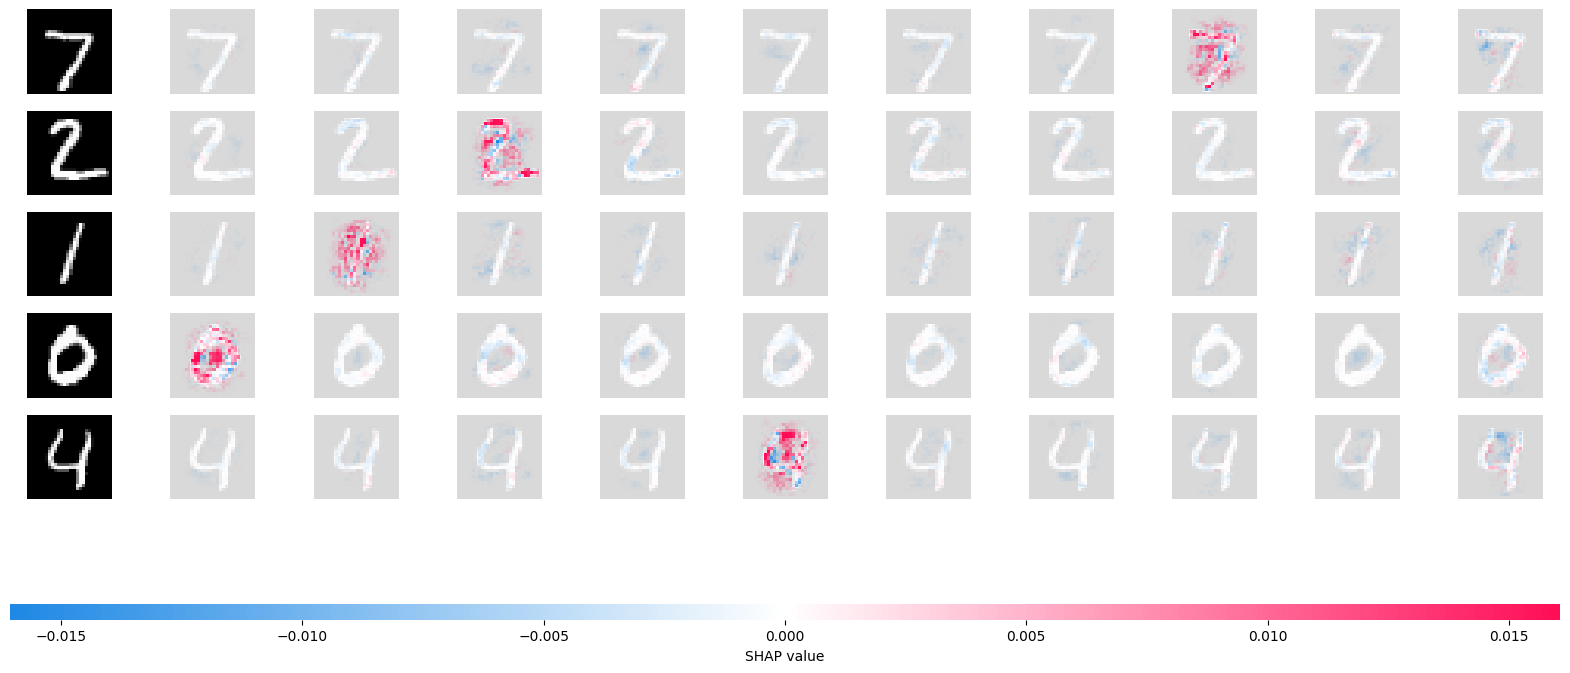

In [18]:
import shap


background = x_train[np.random.choice(x_train.shape[0], 100, replace=False)]


explainer = shap.DeepExplainer(model, background)


images_to_explain = x_test[:5]
shap_values = explainer.shap_values(images_to_explain)

if isinstance(shap_values, list):
    shap_plot = [np.expand_dims(sv, -1) for sv in shap_values]
else:  
    shap_plot = [shap_values[..., i] for i in range(shap_values.shape[-1])]
    shap_plot = [np.expand_dims(sv, -1) for sv in shap_plot]

test_plot = np.expand_dims(images_to_explain, -1)
shap.image_plot(shap_plot, test_plot)

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 179.23it/s]


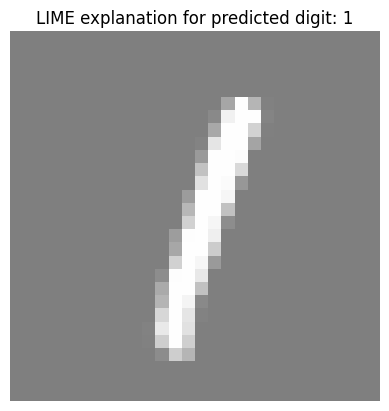

In [21]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_explainer = lime_image.LimeImageExplainer()


def predict_fn(images):
    gray = images[:, :, :, 0]
    return model.predict(gray, verbose=0)


image = x_test[5]
image_rgb = np.stack([image] * 3, axis=-1).astype("double")

explanation = lime_explainer.explain_instance(
    image_rgb,
    predict_fn,
    top_labels=1,       
    hide_color=0,
    num_samples=1000,   
)


label = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(
    label,
    positive_only=True,   
    num_features=5,       
    hide_rest=False,
)

plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title(f"LIME explanation for predicted digit: {label}")
plt.axis("off")
plt.show()